In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
tomato_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/rice_gene_results.csv', index_col= 0)
tomato_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/rice_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
arabi_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/arabi_gene_results.csv', index_col= 0)
arabi_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/arabi_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [3]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [4]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10238at3193,144.205505,0.104383,0.269987,0.386621,6.990367e-01,7.756038e-01
103112at3193,156.146318,-1.588865,0.279959,-5.675339,1.384142e-08,7.358532e-08
104149at3193,1006.454646,0.205956,0.141392,1.456638,1.452163e-01,2.208891e-01
104563at3193,276.946403,-1.711578,0.217056,-7.885411,3.135016e-15,2.797629e-14
105793at3193,730.814044,0.306722,0.141361,2.169788,3.002294e-02,5.761699e-02
...,...,...,...,...,...,...
9789at3193,468.891041,0.671112,0.163991,4.092379,4.269708e-05,1.498396e-04
9797at3193,164.587090,0.464617,0.268912,1.727767,8.403003e-02,1.398510e-01
9814at3193,314.012595,-0.023116,0.193237,-0.119627,9.047786e-01,9.288168e-01
9942at3193,1800.013453,0.065816,0.108469,0.606772,5.440021e-01,6.419773e-01


In [6]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [7]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [8]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [9]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10772at3193,0.406150,25.192556,0.004198,0.619886,0.006773,9.945964e-01,9.953931e-01
10950at3193,-0.128112,4315.100567,0.863399,0.094077,9.177561,4.409648e-20,5.265900e-19
109808at3193,0.837605,368.116273,-0.004505,0.184440,-0.024428,9.805116e-01,9.859968e-01
109841at3193,0.031782,180.070284,0.142496,0.244235,0.583439,5.595980e-01,6.574838e-01
109843at3193,0.186384,792.351316,-0.421695,0.158881,-2.654157,7.950686e-03,1.795131e-02
...,...,...,...,...,...,...,...
9450at3193,0.274216,2146.187548,0.171917,0.106932,1.607724,1.078957e-01,1.731135e-01
9592at3193,0.606275,621.133714,0.003330,0.155239,0.021449,9.828875e-01,9.870560e-01
9601at3193,-0.299745,1485.753488,0.379697,0.114117,3.327261,8.770412e-04,2.429527e-03
9609at3193,0.008053,336.380432,0.352092,0.199466,1.765172,7.753492e-02,1.310784e-01


In [10]:
log_fc_change_evaluation_value

1.5

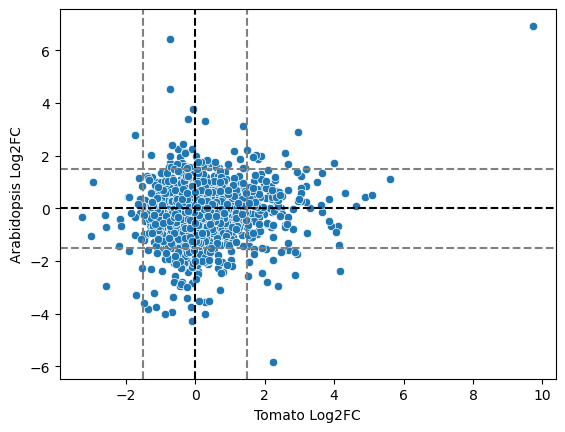

In [11]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n Sorghum Drought')

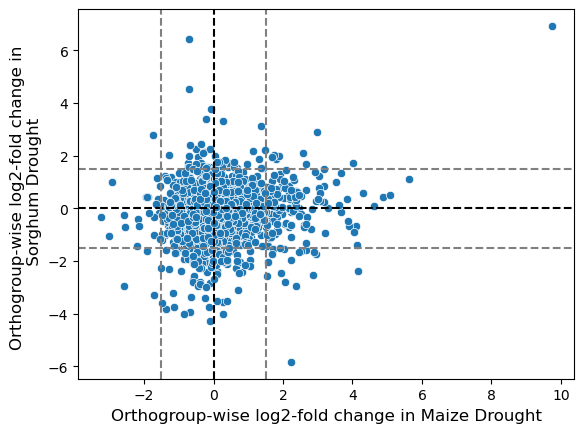

In [12]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Orthogroup-wise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n Sorghum Drought", fontsize = 12)

In [13]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,2411.633843,0.406150,0.237494,1.710151,0.087238,0.166693
10950at3193,2117.226134,-0.128112,0.239570,-0.534758,0.592817,0.709825
109808at3193,77.349255,0.837605,0.502047,1.668381,0.095240,0.178413
109841at3193,176.722364,0.031782,0.249482,0.127394,0.898629,0.939119
109843at3193,1008.117231,0.186384,0.239332,0.778766,0.436117,0.570527
...,...,...,...,...,...,...
9450at3193,4654.030287,0.274216,0.273276,1.003437,0.315650,0.449796
9592at3193,571.094959,0.606275,0.199227,3.043138,0.002341,0.009025
9601at3193,367.784780,-0.299745,0.184619,-1.623584,0.104465,0.190875
9609at3193,786.419667,0.008053,0.267528,0.030102,0.975986,0.983246


In [14]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [15]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [16]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_1644925/2994845458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_1644925/2994845458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
/tmp/ipykernel_1644925/2994845458.py:4: SettingWithCopyWarning: 
A value is trying to be set on a cop

Text(0, 0.5, 'Orthogroup-wise log2-fold change in Sorghum Drought')

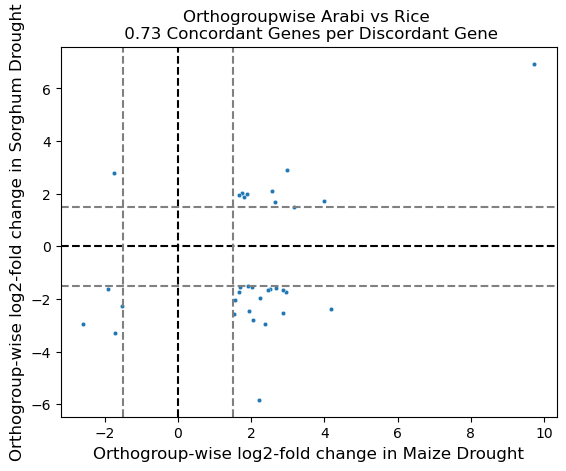

In [20]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Orthogroupwise Arabi vs Rice \n 0.73 Concordant Genes per Discordant Gene')
plt.xlabel("Orthogroup-wise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in Sorghum Drought", fontsize = 12)

In [21]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

0.7368421052631579

In [22]:
discord_bottom

,Tomato,Arabi
152,2.227039,-5.839794
153,2.033347,-1.554382
171,4.170562,-2.395216
212,1.527579,-2.570097
239,1.708330,-1.542232
311,1.937247,-2.461355
381,1.684138,-1.721691
622,2.865911,-2.524036
855,1.913296,-1.500984
861,2.231491,-1.956834


In [23]:
discord_top

,Tomato,Arabi
950,-1.733766,2.771884


In [24]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.8285012285012285
0.8285012285012285
0.8285012285012285
0.8285012285012285


In [25]:
arabi_disconcordant_change

,Tomato,Arabi
13,-0.493083,2.271461
18,2.039187,-0.012715
22,1.296391,0.595788
25,0.645326,1.375837
26,0.845505,1.386173
...,...,...
2002,2.381579,-2.937319
2007,1.337655,-0.221531
2009,1.229542,0.202470
2010,1.562999,0.186785


In [26]:
tomato_any_change

,Tomato,Arabi
0,0.004198,0.406150
1,0.863399,-0.128112
2,-0.004505,0.837605
3,0.142496,0.031782
4,-0.421695,0.186384
...,...,...
2030,0.171917,0.274216
2031,0.003330,0.606275
2032,0.379697,-0.299745
2033,0.352092,0.008053


In [25]:
tomato_concordant_change

,Tomato,Arabi
0,3.631205,1.191514
1,-0.851444,0.004198
2,0.508823,-1.430932
5,-1.872667,-0.004505
6,-0.736159,0.142496
...,...,...
2717,0.959002,0.352092
2718,0.040918,0.671112
2719,0.710791,0.464617
2720,0.237622,0.065816


In [28]:
arabidopsis_tomato_nm = pd.read_csv('/vault/transfer/passala/OrthoDB_data/V_11_pairwise_maps_fixed_problem_species/rice_jp_to_arabidopsis_ortholog_NM.csv')

In [29]:
arabidopsis_tomato_nm

,rice_jp OrthoGene,arabidopsis OrthoGene,Orthogroup,rice_jp Symbol,arabidopsis Symbol
0,39947_0:0033f9,3702_0:001f5f,10092at3193,Os05g0333200,AT2G26300
1,39947_0:005347,3702_0:000e32,10147at3193,Os08g0137200,AT1G73910
2,39947_0:005347,3702_0:0018a2,10147at3193,Os08g0137200,AT1G18450
3,39947_0:00028f,3702_0:000573,10228at3193,Os01g0575500,AT1G49040
4,39947_0:001fe4,3702_0:0012bf,10238at3193,Os03g0668400,AT1G79120
...,...,...,...,...,...
42864,39947_0:0048a3,3702_0:003134,9942at3193,Os07g0271000,AT3G59920
42865,39947_0:0020d4,3702_0:005540,9942at3193,Os03g0277000,AT5G09550
42866,39947_0:003388,3702_0:005540,9942at3193,Os05g0304400,AT5G09550
42867,39947_0:003b6c,3702_0:005540,9942at3193,Os05g0418000,AT5G09550


In [34]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'rice_jp Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'arabidopsis Symbol',)
arabidopsis_tomato_nm

,rice_jp OrthoGene,arabidopsis OrthoGene,Orthogroup,rice_jp Symbol,arabidopsis Symbol
0,39947_0:0033f9,3702_0:001f5f,10092at3193,Os05g0333200,AT2G26300
1,39947_0:005347,3702_0:000e32,10147at3193,Os08g0137200,AT1G73910
3,39947_0:00028f,3702_0:000573,10228at3193,Os01g0575500,AT1G49040
4,39947_0:001fe4,3702_0:0012bf,10238at3193,Os03g0668400,AT1G79120
6,39947_0:001992,3702_0:0003d0,10488at3193,LOC4329458,AT1G08260
...,...,...,...,...,...
42850,39947_0:006dee,3702_0:00121f,9828at3193,Os12g0638900,AT1G74750
42852,39947_0:003d49,3702_0:0052b3,9836at3193,LOC4340090,AT5G11380
42853,39947_0:00158e,3702_0:001def,9877at3193,Os02g0232400,AT2G42790
42856,39947_0:00335b,3702_0:00114d,9919at3193,Os05g0519500,AT1G15440


In [41]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['arabidopsis Symbol','rice_jp Symbol']], right_on= 'arabidopsis Symbol')
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = 'arabidopsis Symbol', keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,arabidopsis Symbol,rice_jp Symbol
31818,279.396501,0.829770,0.279637,2.967315,3.004133e-03,1.130115e-02,AT1G01020,Os03g0784300
31329,1560.891356,-0.150400,0.209226,-0.718841,4.722388e-01,6.123648e-01,AT1G01040,LOC4331440
36257,459.968316,-4.223425,0.429055,-9.843555,7.308207e-23,9.550299e-21,AT1G01060,Os08g0157600
26663,582.916252,-0.503319,0.300694,-1.673856,9.415888e-02,1.844520e-01,AT1G01080,Os08g0117100
30418,1186.453103,-1.414880,0.296349,-4.774371,1.802694e-06,1.950987e-05,AT1G01090,Os04g0119400
...,...,...,...,...,...,...,...,...
14250,1544.917312,0.097392,0.256502,0.379692,7.041741e-01,8.035375e-01,AT5G67370,Os03g0439700
28710,185.116966,-0.513193,0.321379,-1.596844,1.103005e-01,2.080880e-01,AT5G67390,Os03g0762100
15290,575.977171,0.409068,0.213675,1.914439,5.556413e-02,1.219793e-01,AT5G67490,Os06g0157800
32128,526.096191,0.062253,0.182887,0.340391,7.335620e-01,8.250629e-01,AT5G67530,LOC4331972


In [42]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['arabidopsis Symbol','rice_jp Symbol']], right_on= 'rice_jp Symbol')
tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = 'rice_jp Symbol', keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,arabidopsis Symbol,rice_jp Symbol
4355,1173.668182,-0.452103,0.132250,-3.418541,6.295781e-04,2.080418e-03,AT2G43490,Os01g0100100
23078,1313.645813,-0.097851,0.131237,-0.745600,4.559090e-01,5.794364e-01,AT2G37270,Os01g0100700
30673,2395.431575,-0.068746,0.117539,-0.584880,5.586285e-01,6.720552e-01,AT1G27980,Os01g0100900
6279,50.145130,-0.121051,0.450544,-0.268677,7.881783e-01,8.565717e-01,AT4G24880,Os01g0101300
42229,2656.788341,-0.195300,0.118501,-1.648085,9.933530e-02,1.739749e-01,AT3G23900,Os01g0101600
...,...,...,...,...,...,...,...,...
42850,2771.755898,0.472402,0.111226,4.247226,2.164331e-05,9.296667e-05,AT1G74750,Os12g0638900
7214,637.354476,0.626580,0.156505,4.003573,6.239290e-05,2.487483e-04,AT1G74780,Os12g0639100
17052,5241.230952,-0.340263,0.113528,-2.997182,2.724878e-03,7.774809e-03,AT3G63520,Os12g0640600
40560,3525.819092,0.748280,0.117151,6.387332,1.688044e-10,1.315701e-09,AT2G01980,Os12g0641100


In [43]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,arabidopsis Symbol,rice_jp Symbol
4355,1173.668182,-0.452103,0.132250,-3.418541,6.295781e-04,2.080418e-03,AT2G43490,Os01g0100100
23078,1313.645813,-0.097851,0.131237,-0.745600,4.559090e-01,5.794364e-01,AT2G37270,Os01g0100700
30673,2395.431575,-0.068746,0.117539,-0.584880,5.586285e-01,6.720552e-01,AT1G27980,Os01g0100900
6279,50.145130,-0.121051,0.450544,-0.268677,7.881783e-01,8.565717e-01,AT4G24880,Os01g0101300
42229,2656.788341,-0.195300,0.118501,-1.648085,9.933530e-02,1.739749e-01,AT3G23900,Os01g0101600
...,...,...,...,...,...,...,...,...
42850,2771.755898,0.472402,0.111226,4.247226,2.164331e-05,9.296667e-05,AT1G74750,Os12g0638900
7214,637.354476,0.626580,0.156505,4.003573,6.239290e-05,2.487483e-04,AT1G74780,Os12g0639100
17052,5241.230952,-0.340263,0.113528,-2.997182,2.724878e-03,7.774809e-03,AT3G63520,Os12g0640600
40560,3525.819092,0.748280,0.117151,6.387332,1.688044e-10,1.315701e-09,AT2G01980,Os12g0641100


In [44]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed['rice_jp Symbol'].isin(tomato_genes_trimmed['rice_jp Symbol'])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed['rice_jp Symbol'].isin(arabi_genes_trimmed['rice_jp Symbol'])]


In [45]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,arabidopsis Symbol,rice_jp Symbol
4355,1173.668182,-0.452103,0.132250,-3.418541,6.295781e-04,2.080418e-03,AT2G43490,Os01g0100100
23078,1313.645813,-0.097851,0.131237,-0.745600,4.559090e-01,5.794364e-01,AT2G37270,Os01g0100700
30673,2395.431575,-0.068746,0.117539,-0.584880,5.586285e-01,6.720552e-01,AT1G27980,Os01g0100900
6279,50.145130,-0.121051,0.450544,-0.268677,7.881783e-01,8.565717e-01,AT4G24880,Os01g0101300
42229,2656.788341,-0.195300,0.118501,-1.648085,9.933530e-02,1.739749e-01,AT3G23900,Os01g0101600
...,...,...,...,...,...,...,...,...
42850,2771.755898,0.472402,0.111226,4.247226,2.164331e-05,9.296667e-05,AT1G74750,Os12g0638900
7214,637.354476,0.626580,0.156505,4.003573,6.239290e-05,2.487483e-04,AT1G74780,Os12g0639100
17052,5241.230952,-0.340263,0.113528,-2.997182,2.724878e-03,7.774809e-03,AT3G63520,Os12g0640600
40560,3525.819092,0.748280,0.117151,6.387332,1.688044e-10,1.315701e-09,AT2G01980,Os12g0641100


In [46]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index('rice_jp Symbol')
          .reindex(arabi_genes_trimmed.set_index('rice_jp Symbol').index)
          .reset_index()
       )

In [47]:
tomato_genes_trimmed

,rice_jp Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,arabidopsis Symbol
0,Os03g0784300,135.254483,-0.000507,0.285319,-0.001777,0.998582,0.999150,AT1G01020
1,Os08g0157600,1045.936487,0.287973,0.133782,2.152552,0.031354,0.066007,AT1G01060
2,Os08g0117100,639.876854,-0.340670,0.171628,-1.984929,0.047152,0.093582,AT1G01080
3,Os04g0119400,1413.799806,0.352998,0.127665,2.765024,0.005692,0.014904,AT1G01090
4,Os08g0116500,3808.530436,-0.158486,0.130744,-1.212178,0.225444,0.337470,AT1G01100
...,...,...,...,...,...,...,...,...
5189,Os07g0155100,513.254440,-0.503893,0.170501,-2.955373,0.003123,0.008788,AT5G67290
5190,Os07g0589600,70.497556,0.429588,0.425903,1.008652,0.313141,0.437316,AT5G67350
5191,Os03g0439700,739.959123,-0.557180,0.199979,-2.786195,0.005333,0.014067,AT5G67370
5192,Os06g0157800,157.139498,-0.425787,0.266657,-1.596759,0.110319,0.190088,AT5G67490


In [48]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

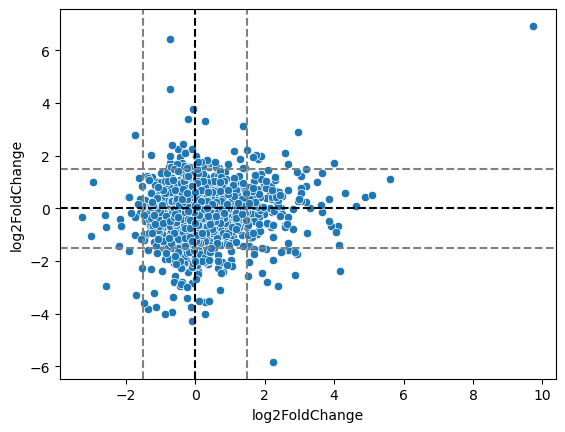

In [49]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Genewise log2-fold change in \n Sorghum Drought')

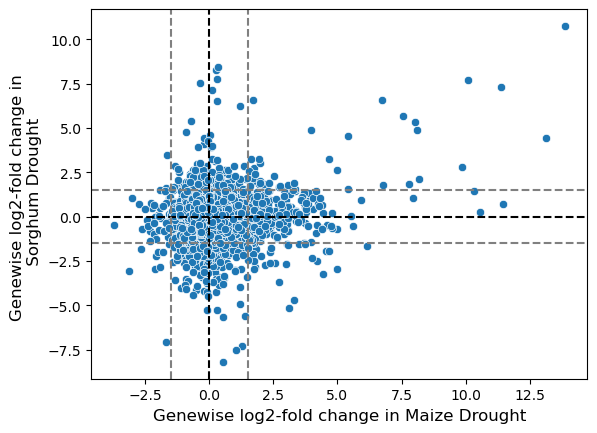

In [50]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Genewise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n Sorghum Drought", fontsize = 12)

In [51]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [52]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_1644925/1856289886.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_1644925/1856289886.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
/tmp/ipykernel_1644925/1856289886.py:4: SettingWithCopyWarning: 
A value is t

Text(0, 0.5, 'Genewise log2-fold change in Sorghum Drought')

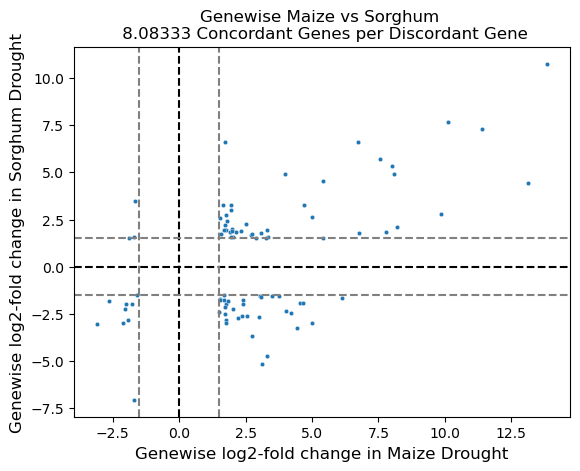

In [53]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10 )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Genewise Maize vs Sorghum \n 8.08333 Concordant Genes per Discordant Gene')
plt.xlabel("Genewise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in Sorghum Drought", fontsize = 12)

In [ ]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

1.4857142857142858

In [342]:
all_over_1

,Tomato,Arabi
128,5.420722,2.289623
163,2.688214,1.658393
165,1.529409,1.995355
351,6.788676,2.372646
582,7.428141,2.349108
660,4.131078,2.303250
847,4.748212,2.510446
968,5.096113,2.105806
1064,3.039029,1.728921
1218,2.317202,3.015622


In [343]:
all_under_1

,Tomato,Arabi
1302,-1.546548,-1.996698
3401,-1.570759,-1.713524
4504,-1.584948,-4.405051
4944,-5.482556,-1.861803
5162,-1.628072,-2.431291


In [344]:
merged_result

,Tomato,Arabi
0,-0.145039,0.054831
1,-0.023699,-0.092506
2,0.074602,-0.769619
3,-0.647447,-0.563822
4,-0.407818,-0.445230
...,...,...
3199,2.262803,0.036704
3200,0.376672,0.168016
3201,0.401132,0.728854
3202,-0.146726,-0.288193


In [345]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.6387687188019967
0.6387687188019967
0.6387687188019967
0.6387687188019967


In [346]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

SignificanceResult(statistic=0.3778838983240342, pvalue=2.6260518647079396e-203)

In [347]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [348]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [349]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

5

In [350]:
up_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
114446at3193,1241.209942,3.515908,0.459146,7.657494,1.895955e-14,3.277839e-13
118011at3193,572.664338,2.646269,0.254130,10.413035,2.162169e-25,1.102920e-23
118239at3193,218.445035,2.275324,0.171891,13.236980,5.366364e-40,6.143890e-38
118532at3193,1725.105212,2.161990,0.139590,15.488117,4.173376e-54,1.023868e-51
127999at3193,39.111363,2.056699,0.405571,5.071118,3.954849e-07,2.217125e-06
136845at3193,242.212243,2.145751,0.298576,7.186620,6.641495e-13,9.452205e-12
137296at3193,707.220252,2.480940,0.193344,12.831742,1.088883e-37,1.121985e-35
138520at3193,44.488378,4.133091,0.588411,7.024155,2.153657e-12,2.760110e-11
139009at3193,99.410629,2.081851,0.330890,6.291672,3.140650e-10,2.958068e-09
139101at3193,78.287068,2.997948,0.494597,6.061394,1.349466e-09,1.164564e-08


In [351]:
up_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
137296at3193,2161.067885,2.174250,0.528502,4.113983,3.888909e-05,5.491535e-04
138520at3193,76.412410,2.153709,0.393055,5.479408,4.267515e-08,1.911330e-06
402643at3193,166.541104,2.019380,0.352363,5.730967,9.985962e-09,5.466390e-07
404029at3193,194.154600,2.164346,0.350151,6.181175,6.362634e-10,5.037842e-08
649605at3193,47.270308,2.015115,0.408406,4.934102,8.052030e-07,2.190350e-05
685441at3193,81.660743,2.091774,0.416022,5.028042,4.955136e-07,1.445465e-05


In [352]:
up

,sorghum Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol
100,LOC8079693,195.258840,2.983458,0.416281,7.166938,7.669375e-13,1.113223e-11,Zm00001d034723
128,LOC8057046,2520.801630,5.420722,0.532738,10.175209,2.558510e-24,1.155618e-22,Zm00001d034643
163,LOC8057096,41.640932,2.688214,0.455019,5.907911,3.464740e-09,3.055697e-08,Zm00001d034571
304,LOC8060482,183.413908,3.368102,0.296143,11.373238,5.683920e-30,3.862100e-28,Zm00001d033990
319,LOC110436814,41370.139495,2.435272,0.166060,14.664978,1.080524e-48,2.059321e-46,Zm00001d033931
...,...,...,...,...,...,...,...,...
5726,LOC8070713,1006.526721,2.215971,0.333194,6.650688,2.917258e-11,3.443422e-10,Zm00001d045392
5747,LOC8071335,1115.939142,2.910148,0.192626,15.107733,1.440095e-51,3.246030e-49,Zm00001d045311
5759,LOC8076148,63.523609,2.440673,0.484010,5.042613,4.592178e-07,2.807768e-06,Zm00001d045204
5776,LOC8065428,25.333567,3.370250,0.568750,5.925710,3.109504e-09,2.760053e-08,Zm00001d037080


In [353]:
up_arabi

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,sorghum Symbol
128,9124,3100.928023,2.289623,0.461379,4.962561,6.956980e-07,2.118509e-05,Zm00001d034643,LOC8057046
964,5026,2995.168619,2.039980,0.150657,13.540539,9.012488e-42,1.756444e-37,Zm00001d032293,LOC8080108
968,48187,94.957402,2.105806,0.487992,4.315252,1.594213e-05,2.832235e-04,Zm00001d029349,LOC8080751
1271,14949,497.115989,3.143004,0.753548,4.170939,3.033474e-05,4.760014e-04,Zm00001d028408,LOC8054347
1842,38483,198.980996,2.434358,0.367586,6.622557,3.530374e-11,4.169907e-09,Zm00001d005283,LOC8062599
2523,10803,4971.656556,2.025416,0.276492,7.325419,2.381541e-13,4.945837e-11,Zm00001d039315,LOC8081371
2591,13898,4238.575944,2.140743,0.519352,4.121947,3.756841e-05,5.671346e-04,Zm00001d039566,LOC8078754
2609,37520,47.242209,2.009489,0.416134,4.828946,1.372575e-06,3.794341e-05,Zm00001d039634,LOC8078789
2665,32132,972.246781,3.103060,0.639684,4.850928,1.228853e-06,3.460856e-05,Zm00001d039942,LOC8061349
2977,68022,552.870627,2.066635,0.272540,7.582869,3.379950e-14,9.541208e-12,Zm00001d044124,LOC8058201


In [354]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)

KeyError: 'arabidopsis Symbol'